In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
from scipy.stats import zscore



In [2]:
# Load dataset
df= pd.read_csv("data/AmesHousing_engineered.csv")

# Drop target and ID columns
X = df.drop(columns=["SalePrice", "PID", "Order"], errors="ignore")
# Apply StandardScaler
scaler = StandardScaler()
X_spo = scaler.fit_transform(X)

print("Scaled features shape:", X_spo.shape)

Scaled features shape: (2930, 172)


In [3]:
#Define Clustering Parameters
k_values = range(2, 9)  # clusters for KMeans, GMM, Agglomerative, Spectral
n_init = 10              # random initialization
dbscan_eps = [0.5, 1.0, 1.5]  # DBSCAN eps values
min_samples = 5

In [4]:
#Function to Compute Metrics
def compute_metrics(X_data, labels):
    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    return sil, db, ch

In [5]:
#Apply PCA
# Keep 95% variance
#pca = PCA(n_components=0.95, random_state=42)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_spo)
#print("PCA features shape:", X_pca.shape)
print("PCA-reduced features shape:", X_pca.shape)
print("Explained variance ratio sum:", sum(pca.explained_variance_ratio_))

PCA-reduced features shape: (2930, 25)
Explained variance ratio sum: 0.9587142612380308


In [6]:
#Outlier Detection & Removal (Z-score)
# Compute z-scores on PCA components
z_scores = np.abs(zscore(X_pca))

# Threshold (e.g., z > 3)
threshold = 3
mask = (z_scores < threshold).all(axis=1)

X_final = X_pca[mask]

print("Shape after PCA + Outlier Removal:", X_final.shape)

Shape after PCA + Outlier Removal: (2650, 25)


In [7]:
#K-Means on Scaled + PCA + outliersremoval Data
results_scal_pca_out = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
    labels = km.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out.append({"algorithm": "KMeans", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

In [8]:
#Gaussian Mixture (GMM)on Scaled + PCA + outliersremoval Data
results_scal_pca_out_gmm = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, n_init=n_init, random_state=42)
    labels = gmm.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out_gmm.append({"algorithm": "GMM", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

In [9]:
#Agglomerative Clustering on Scaled + PCA + outliersremoval Data
results_scal_pca_out_agg = []
for k in k_values:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out_agg.append({"algorithm": "Agglomerative", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

In [10]:
#Spectral Clustering on Scaled + PCA + outliersremoval Data
results_scal_pca_out_spec = []
for k in k_values:
    spec = SpectralClustering(n_clusters=k, affinity="nearest_neighbors")
    labels = spec.fit_predict(X_final)
    sil, db, ch = compute_metrics(X_final, labels)
    results_scal_pca_out_spec.append({"algorithm": "Spectral", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "k": k, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})

In [11]:
#DBSCAN on Scaled + PCA + outliersremoval Data
results_scal_pca_out_dbscan = []
for eps in dbscan_eps:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_final)
    
    # Remove noise points (-1)
    mask = labels != -1
    if np.sum(mask) > 1:  # silhouette requires >= 2 points
        sil, db, ch = compute_metrics(X_final[mask], labels[mask])
        results_scal_pca_out_dbscan.append({"algorithm": "DBSCAN", "preprocessing": "StandardScaler+PCA+OutlierRemoval", "eps": eps, "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch})


In [12]:
import csv

results_scal_pca_out = (results_scal_pca_out + results_scal_pca_out_gmm + results_scal_pca_out_agg + results_scal_pca_out_spec + results_scal_pca_out_dbscan)

# Desired column order
keys = ["algorithm", "preprocessing", "k", "silhouette", "davies_bouldin", "calinski_harabasz", "eps"]

with open('updated_data/ames_scaled_pca_out_scores.csv', 'w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=keys, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_scal_pca_out)


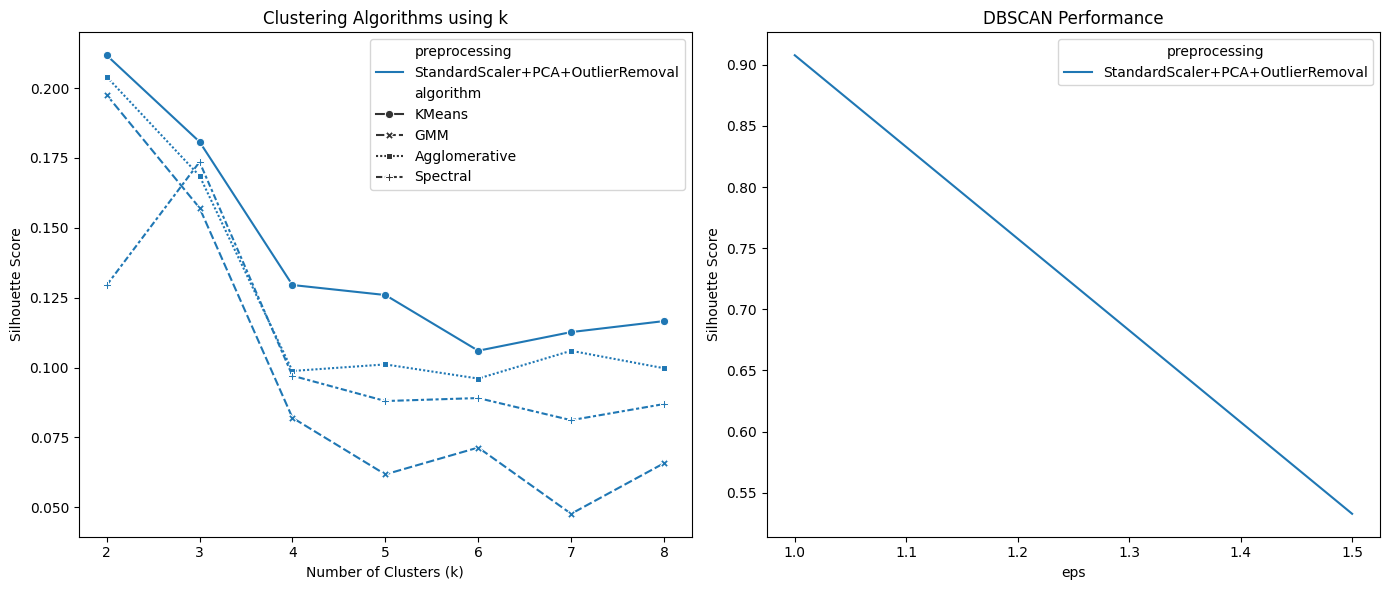

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


df_spo = pd.read_csv("updated_data/ames_scaled_pca_out_scores.csv")
df_spo.columns = df_spo.columns.str.strip().str.lower()
# df_raw.columns = df_raw.columns.str.strip()
#df_raw
df_spo_k = df_spo[df_spo["algorithm"] != "DBSCAN"]
df_spo_dbscan = df_spo[df_spo["algorithm"] == "DBSCAN"]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot algorithms using k
sns.lineplot(
    data=df_spo_k,
    x="k",
    y="silhouette",
    hue="preprocessing",
    style="algorithm",
    markers=True,
    ax=axes[0]
)

axes[0].set_title("Clustering Algorithms using k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")

# Plot DBSCAN
sns.lineplot(
    data=df_spo_dbscan,
    x="eps",
    y="silhouette",
    hue="preprocessing",
    markers=True,
    #ax=axes[1]
)

axes[1].set_title("DBSCAN Performance")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

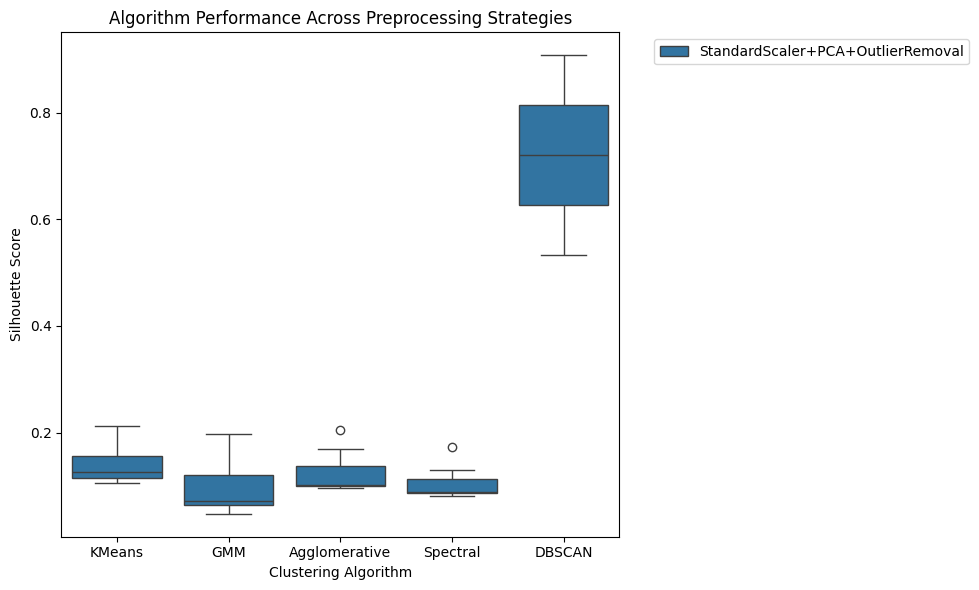

In [24]:

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_spo,
    x="algorithm",
    y="silhouette",
    hue="preprocessing"
)

plt.title("Algorithm Performance Across Preprocessing Strategies")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")

plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

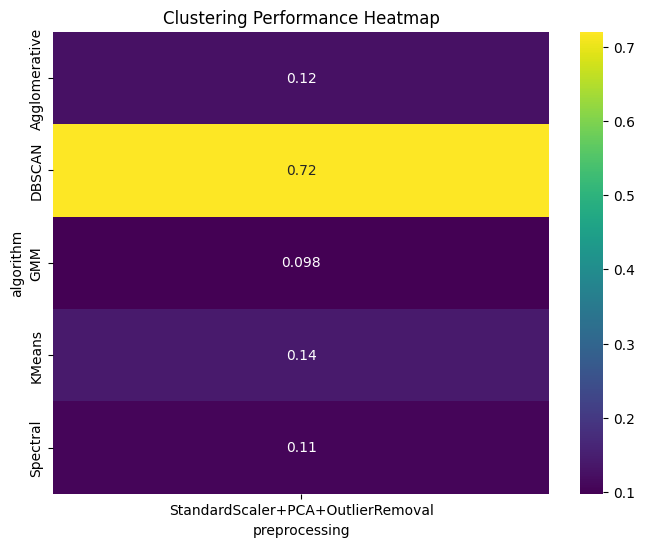

In [25]:
#Preprocessing Impact Heatmap
pivot = df_spo.pivot_table(
    values="silhouette",
    index="algorithm",
    columns="preprocessing"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="viridis"
)

plt.title("Clustering Performance Heatmap")
plt.show()
